In [8]:
import yfinance as yf
import numpy as np
import pandas as pd

In [31]:
tickers = ["PLY.AX","LAU.AX","TLX.AX","COS.AX","ANG.AX",
           "VVA.AX","WTC.AX","AUB.AX","XYZ.AX","DUG.AX"]

data = yf.download(tickers, start="2025-01-13", end="2025-12-31")
shares_outstanding = {t: yf.Ticker(t).info.get('sharesOutstanding') for t in tickers}
epsilon = 1e-10
prices = data["Close"]
returns = prices.pct_change().dropna()
returns = returns.replace(0, epsilon)

[*********************100%***********************]  10 of 10 completed


In [33]:
# Momentum (12-1 style approx)
momentum = prices.pct_change(252).replace(0, epsilon).shift(21)
#momentum = (prices.shift(30) / monthly_df.shift(252)) - 1


# Volatility (risk)
volatility = returns.rolling(60).std()

# Liquidity (log dollar volume)
liquidity = np.log(data["Volume"] * prices)

# Size (IMPORTANT — missing in your model)
size = np.log(prices.multiply(pd.Series(shares_outstanding)))  # proxy for market cap
#data

In [34]:
common_index = returns.index

momentum = momentum.loc[common_index]
volatility = volatility.loc[common_index]
liquidity = liquidity.loc[common_index]
size = size.loc[common_index]

In [35]:
def cs_zscore(df):
    return df.sub(df.mean(axis=1), axis=0).div(df.std(axis=1), axis=0)

momentum_z = cs_zscore(momentum)
volatility_z = cs_zscore(volatility)
liquidity_z = cs_zscore(liquidity)
size_z = cs_zscore(size)

In [43]:
industry_map = {
    "PLY.AX": "Industrials",
    "LAU.AX": "Industrials",
    "TLX.AX": "Healthcare",
    "COS.AX": "Industrials",
    "ANG.AX": "Energy",
    "VVA.AX": "Financials",
    "WTC.AX": "Tech",
    "AUB.AX": "Financials",
    "XYZ.AX": "Materials",
    "DUG.AX": "Energy"
}

industry_df = pd.Series(industry_map)
industry_dummies = pd.get_dummies(industry_df).astype(float)

# drop one column to avoid multicollinearity
industry_dummies = industry_dummies.iloc[:, :-1]

# expand across time to match (Date, Ticker)
industry_expanded = pd.concat(
    [industry_dummies] * len(returns),
    keys=returns.index
)

industry_expanded.index.names = ["Date", "Ticker"]

In [44]:
factors = pd.concat({
    "momentum": momentum_z,
    "volatility": volatility_z,
    "liquidity": liquidity_z,
    "size": size_z
}, axis=1)

# reshape
exposure = factors.stack(level=1)
exposure.index.names = ["Date", "Ticker"]

# add industry
exposure = exposure.join(industry_expanded, how="left")
exposure = exposure.fillna(0)

# Trying

In [77]:
beta_list = []
dates_used = []
factor_names = None
specific_list =[]

for date in returns.index:
    r = returns.loc[date]
    B = exposure.loc[date]

    df = pd.concat([r, B], axis=1).dropna()
    if df.shape[0] < 5:   # avoid underdetermined regression
        continue

    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:]

    X = np.column_stack([np.ones(len(X)), X])

    beta = np.linalg.lstsq(X, y, rcond=None)[0]

    y_hat = X @ beta
    eps = y - y_hat   # <-- THIS is specific return

    beta_list.append(beta)
    specific_list.append(eps)
    dates_used.append(date)

    if factor_names is None:
        factor_names = ["alpha"] + df.columns[1:].tolist()

In [81]:
beta_df = pd.DataFrame(
    beta_list,
    index=dates,
    columns=factor_names
)
specific_df = pd.DataFrame(
    specific_list,
    index=dates_used,
    columns=returns.columns  # stock-level residuals
)

In [82]:
window = 60  # ~3 months daily or 24 months monthly equivalent

factor_cov = []

for t in range(window, len(beta_df)):
    cov_t = beta_df.iloc[t-window:t].cov().values
    factor_cov.append(cov_t)

factor_cov = np.array(factor_cov)

In [85]:
spec_risk = specific_df.rolling(window).std()

In [86]:
w = np.ones(len(tickers)) / len(tickers)
portfolio_risk = []

for t in range(window, len(beta_df)):

    B_t = beta_df.iloc[t].values.reshape(-1, 1)  # (K x 1)

    F_t = factor_cov[t-window]              # (K x K)

    # factor risk
    factor_var = (B_t.T @ F_t @ B_t)[0, 0]

    # idiosyncratic risk
    idio_var = np.sum((spec_risk.iloc[t].values ** 2) * (w ** 2))

    portfolio_risk.append(np.sqrt(factor_var + idio_var))

In [89]:
portfolio_returns = returns.mean(axis=1)  # equal-weight portfolio
hist_risk = portfolio_returns.rolling(60).std()

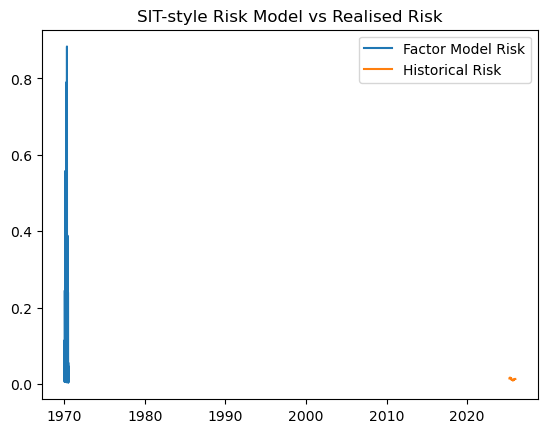

In [90]:
import matplotlib.pyplot as plt

plt.plot(portfolio_risk, label="Factor Model Risk")
plt.plot(hist_risk.iloc[window:], label="Historical Risk")
plt.legend()
plt.title("SIT-style Risk Model vs Realised Risk")
plt.show()

In [91]:
print(beta_df.index.min(), beta_df.index.max())
print(returns.index.min(), returns.index.max())
print(len(beta_df), len(returns))

2025-01-14 00:00:00 2025-12-30 00:00:00
2025-01-14 00:00:00 2025-12-30 00:00:00
244 244


In [92]:
print(factor_cov.shape)

(184, 10, 10)


# Other

In [45]:
print(df.dtypes)

2025-01-14 00:00:00    float64
momentum               float64
volatility             float64
liquidity              float64
size                   float64
Energy                    bool
Financials                bool
Healthcare                bool
Industrials               bool
Materials                 bool
dtype: object


In [57]:
factor_returns = []

for date in returns.index:
    r = returns.loc[date]
    B = exposure.loc[date]

    df = pd.concat([r, B], axis=1).dropna()
    if df.empty:
        factor_returns.append(np.nan)
        continue

    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values

    # add intercept
    X = np.column_stack([np.ones(len(X)), X])

    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    factor_returns.append(beta)

factor_returns = pd.DataFrame(
    factor_returns,
    index=returns.index,
    columns=["alpha"] + list(df.columns[1:])
)

In [58]:
idiosyncratic = []

for date in returns.index:
    r = returns.loc[date]
    B = exposure.loc[date]

    df = pd.concat([r, B], axis=1).dropna()
    if df.empty:
        idiosyncratic.append(np.nan)
        continue

    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values
    X = np.column_stack([np.ones(len(X)), X])

    f = factor_returns.loc[date].values
    eps = y - X @ f

    idiosyncratic.append(pd.Series(eps, index=df.index))

idiosyncratic_df = pd.DataFrame(idiosyncratic, index=returns.index)

In [59]:
# factor covariance
F = factor_returns.drop(columns="alpha").cov()

# latest exposures (NOT average!)
latest_date = returns.index[-1]
B = exposure.loc[latest_date]

# portfolio weights
w = np.ones(len(B)) / len(B)

# portfolio exposure
b_p = B.T @ w

# factor risk
sigma_factor = b_p.T @ F.values @ b_p

# idiosyncratic risk
idio_var = idiosyncratic_df.var().fillna(0)
D = np.diag(idio_var.loc[B.index])

sigma_idio = w.T @ D @ w

print("Factor Risk:", sigma_factor)
print("Idiosyncratic Risk:", sigma_idio)
R2 = pd.Series(R2, index=returns.index)

print("Average R²:", R2.mean())
print(R2.describe())

Factor Risk: 0.008954932008867128
Idiosyncratic Risk: 2.0452866385580472e-05
Average R²: 0.8154809575060377
count    244.000000
mean       0.815481
std        0.188722
min        0.238348
25%        0.695184
50%        0.887243
75%        0.968927
max        0.999985
dtype: float64
